In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
df = pd.read_csv(r'C:\Users\fatim\Documents\customer churn\customer churn.csv')

# Data Quality Assessment

## Missing Value Check

To ensure the dataset is complete and reliable, a missing value check was performed using the `isnull().sum()` function. This verifies whether any column contains null or missing values that could impact the analysis. The results confirmed that all columns have zero missing values, indicating that the dataset is complete and no missing value treatment is required before proceeding with exploratory data analysis.

## Duplicate Record Check

A duplicate record check was conducted using the `duplicated().sum()` function to identify any repeated customer records. The output showed zero duplicate rows, confirming that each customer record is unique and no duplicate removal was necessary.

## Data Type Conversion

The `TotalCharges` column was converted from a string data type to a numeric (`float`) data type. Before conversion, blank spaces were replaced with `0` to prevent conversion errors. This transformation ensures that the column can be used for numerical calculations, statistical analysis, and visualization.

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df["TotalCharges"]=df["TotalCharges"].replace(" ",0)
df["TotalCharges "]=df["TotalCharges"].astype(float)

In [6]:
def conv(value):
 if value == 1:
  return "Yes"
 else:
  return "No"
df["SeniorCitizen"]=df["SeniorCitizen"].apply(conv)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,1889.50
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,108.15
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1840.75
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,151.65


C:\Users\fatim\AppData\Local\Temp\ipykernel_12604\3142684788.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn',data=df,palette=['#3B4A3F', '#52B788'])


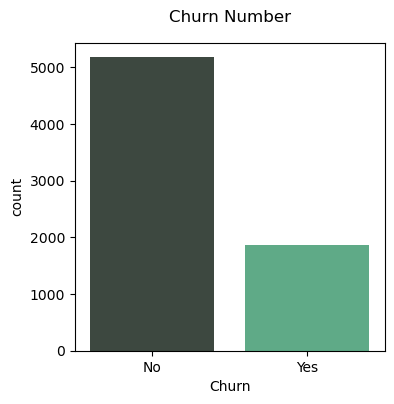

In [7]:
plt.figure(figsize=(4,4))
sns.countplot(x='Churn',data=df,palette=['#3B4A3F', '#52B788'])
plt.title("Churn Number",pad=15)
plt.savefig('churn_number.png', facecolor='white', bbox_inches='tight')
plt.show()

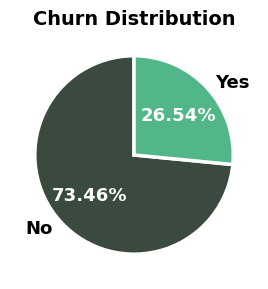

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Your churn value counts
churn_counts = df['Churn'].value_counts()

colors = ['#3B4A3F', '#52B788'] # deep navy + warm coral

fig, ax = plt.subplots(figsize=(3, 3))

wedges, texts, autotexts = ax.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=110)
)

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts:
    text.set_fontsize(13)
    text.set_fontweight('semibold')

ax.set_title('Churn Distribution', fontsize=14, fontweight='bold', pad=5)
plt.savefig('churn_number.png', facecolor='white', bbox_inches='tight')
plt.tight_layout()
plt.show()

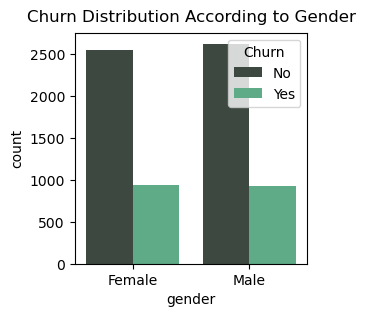

In [9]:
plt.figure(figsize=(3,3))
sns.countplot(x="gender",data=df,palette= ['#3B4A3F', '#52B788'],hue="Churn")
plt.title("Churn Distribution According to Gender",pad=8)
plt.show()

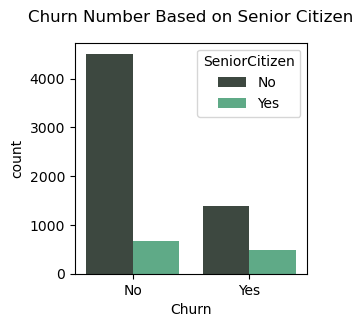

In [10]:
plt.figure(figsize=(3,3))
sns.countplot(x="Churn", data=df, hue="SeniorCitizen", palette=['#3B4A3F', '#52B788'])
plt.title("Churn Number Based on Senior Citizen", pad=15)
plt.show()

C:\Users\fatim\AppData\Local\Temp\ipykernel_12604\60965585.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Senior', 'Senior'])


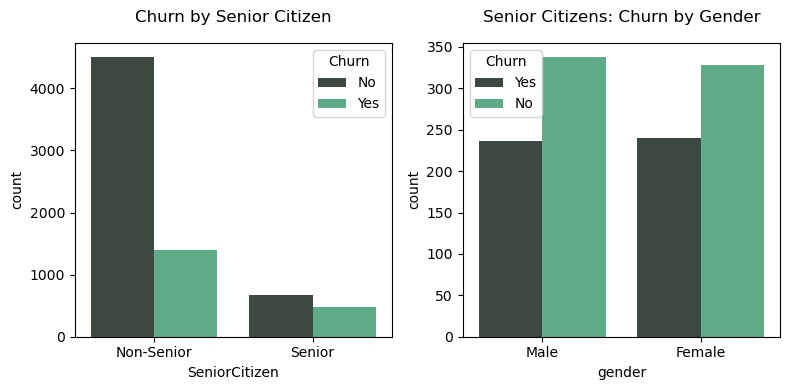

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Plot 1: Churn by Senior Citizen
sns.countplot(x="SeniorCitizen", data=df, hue="Churn", 
              palette=['#3B4A3F', '#52B788'], ax=axes[0])
axes[0].set_title("Churn by Senior Citizen", pad=15)
axes[0].set_xticklabels(['Non-Senior', 'Senior'])

# Plot 2: Senior Citizens only — Churn by Gender
senior_df = df[df["SeniorCitizen"] == "Yes"]
sns.countplot(x="gender", data=senior_df, hue="Churn", 
              palette=['#3B4A3F', '#52B788'], ax=axes[1])
axes[1].set_title("Senior Citizens: Churn by Gender", pad=15)

plt.tight_layout()
plt.show()

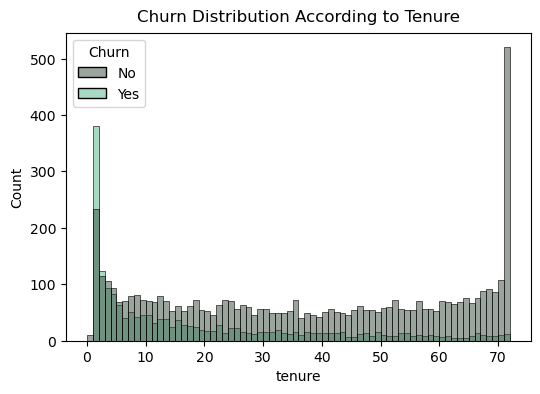

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(x="tenure",data=df,palette= ['#3B4A3F', '#52B788'],hue="Churn",bins=72)
plt.title("Churn Distribution According to Tenure",pad=8)
plt.show()

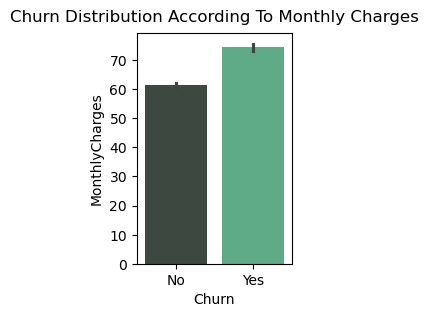

In [13]:
plt.figure(figsize=(2,3))
sns.barplot(x="Churn", y="MonthlyCharges", data=df, hue="Churn", palette=['#3B4A3F','#52B788'], legend=False)
plt.title("Churn Distribution According To Monthly Charges", pad=8)
plt.show()


In [14]:
print((df.columns == "TotalCharges").sum())
print(df.columns.tolist())

1
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalCharges ']


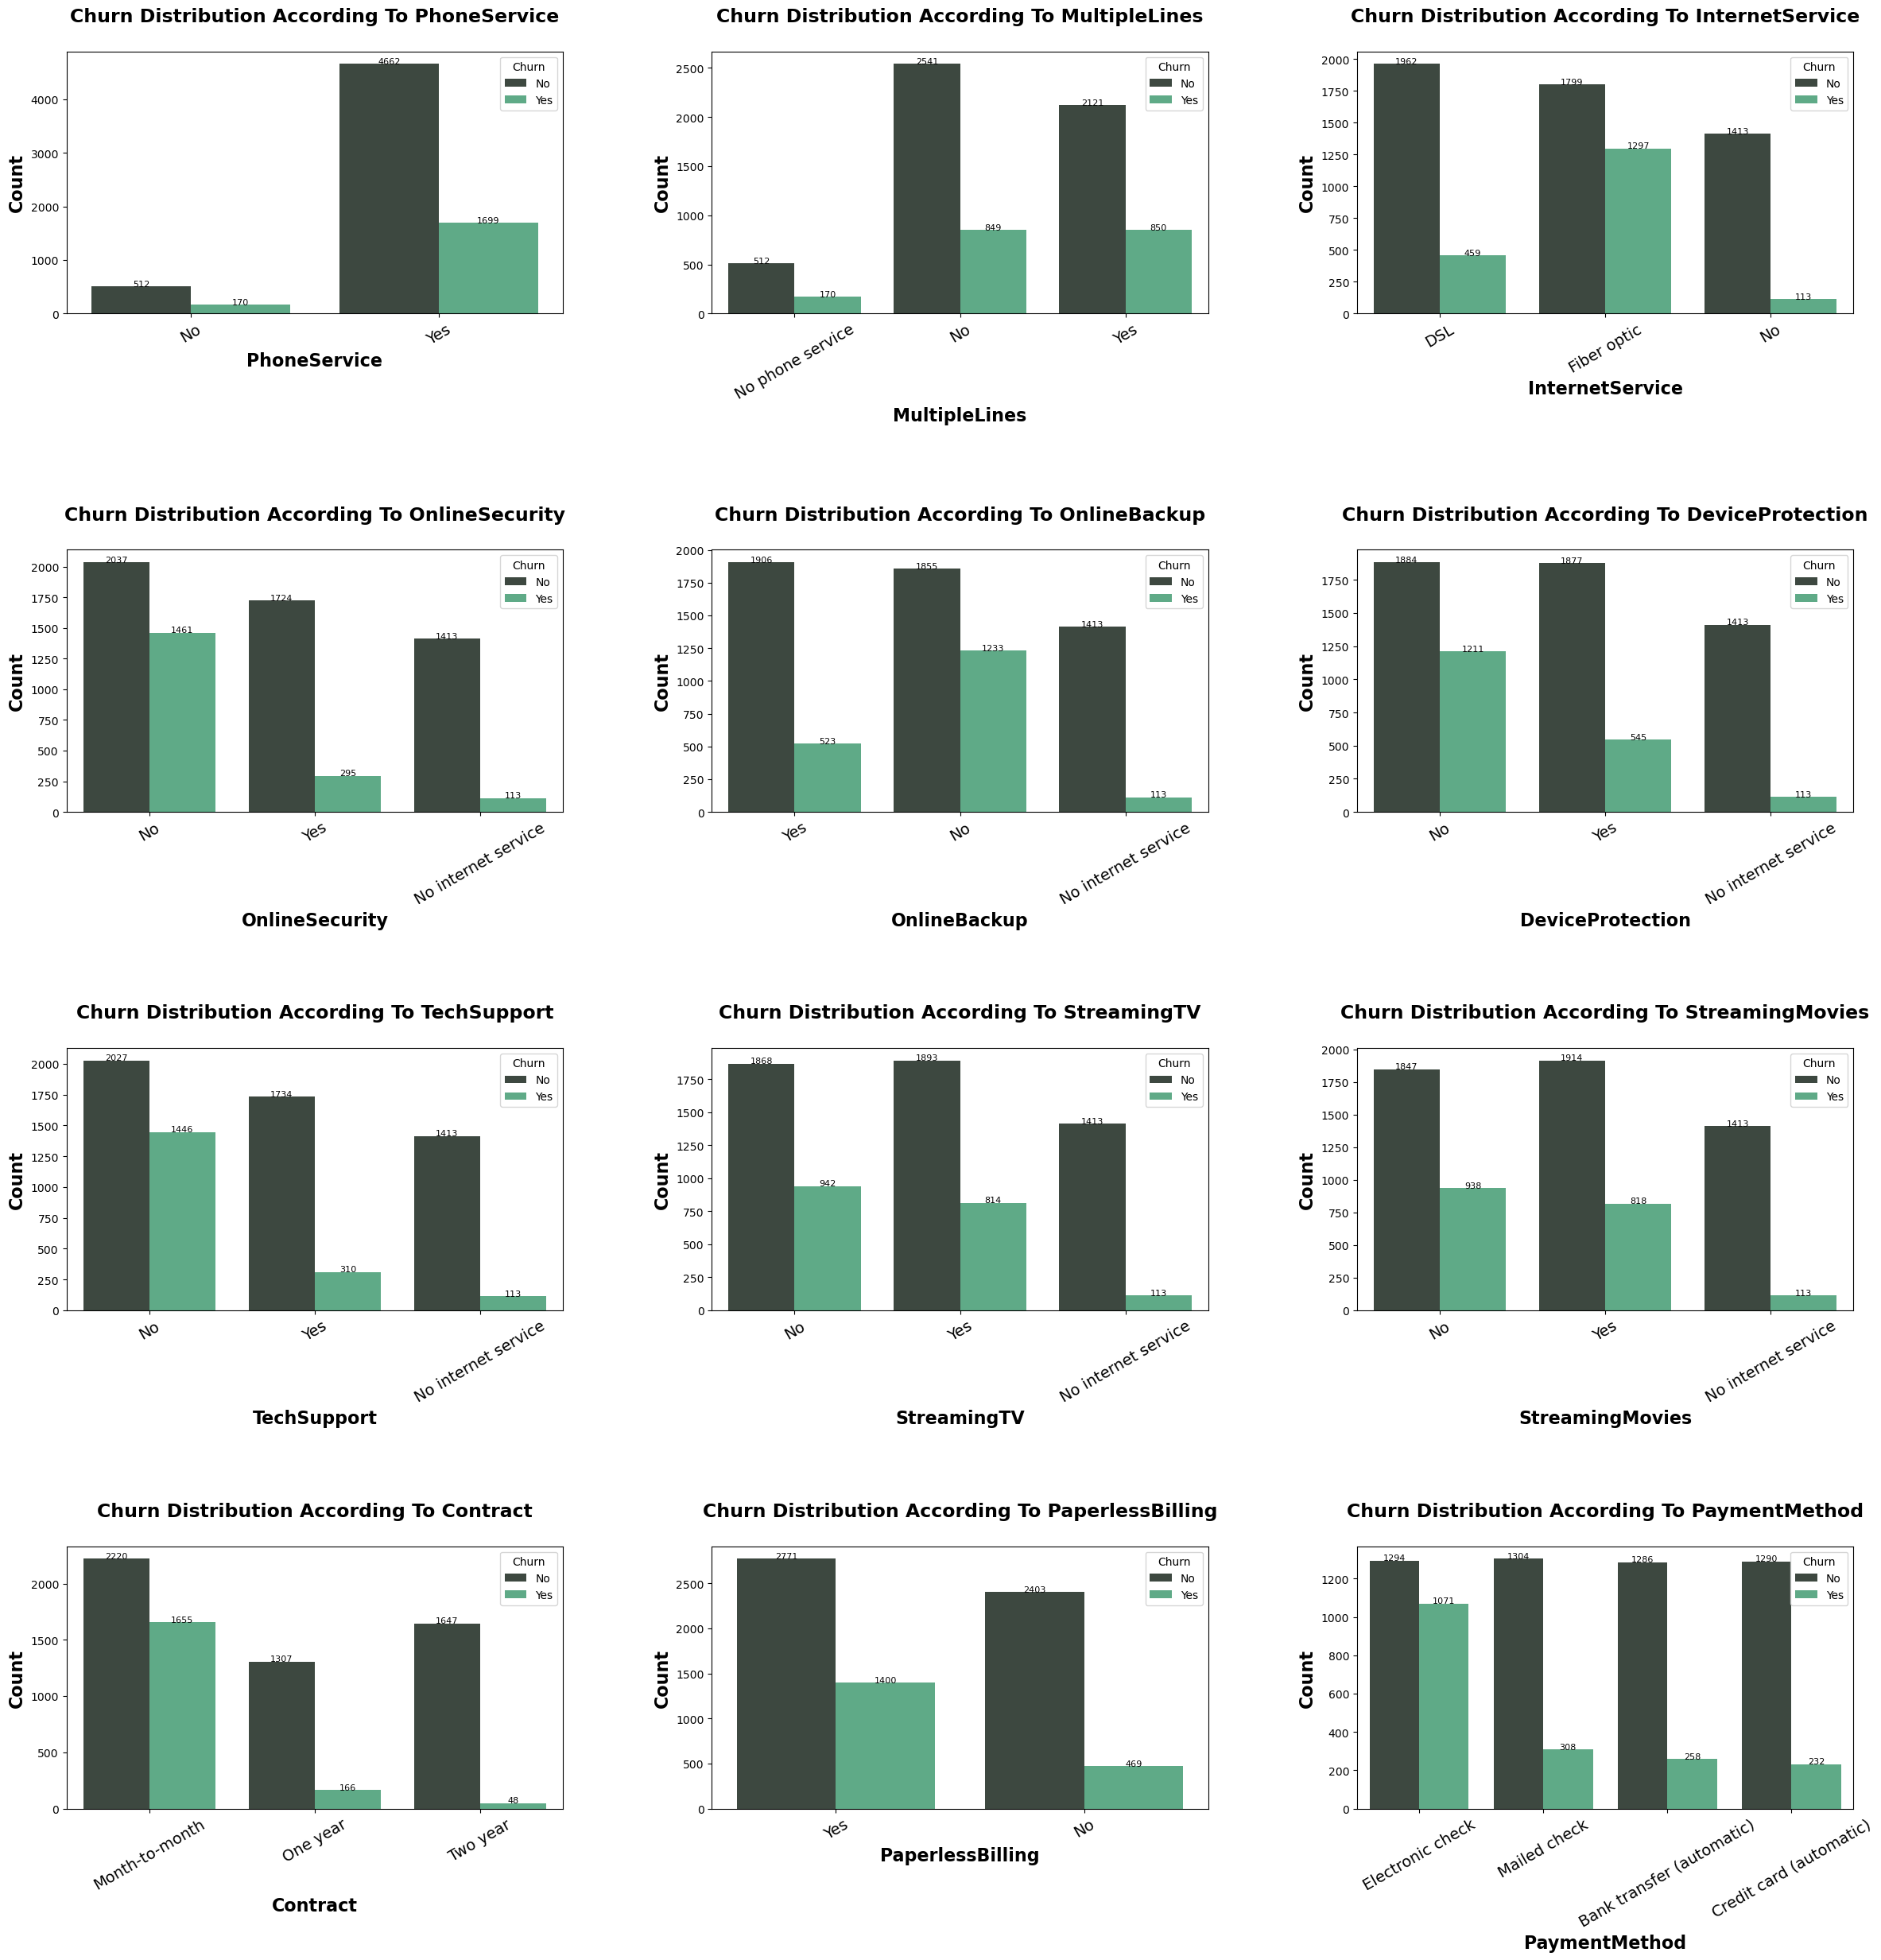

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
            'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# Viridis se 2 distinct shades — dark (No) aur light-yellow-green (Yes)
viridis_colors = [plt.cm.viridis(0.15), plt.cm.viridis(0.75)]

fig, axes = plt.subplots(4, 3, figsize=(29, 26))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, palette=['#3B4A3F','#52B788'], hue="Churn", ax=axes[i])
    axes[i].set_title(f'Churn Distribution According To {col}', fontsize=17, fontweight='bold', pad=27)
    axes[i].set_xlabel(col, fontsize=16,fontweight='bold')
    axes[i].set_ylabel('Count', fontsize=16,fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30, labelsize=14)

    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            axes[i].text(p.get_x() + p.get_width()/2, height + 2,
                         f'{int(height)}', ha='center', fontsize=8)

plt.subplots_adjust(hspace=0.9, wspace=0.3, top=0.96)
plt.show()